In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from sklearn.datasets import make_circles

x,y=make_circles(1000,noise=0.03)

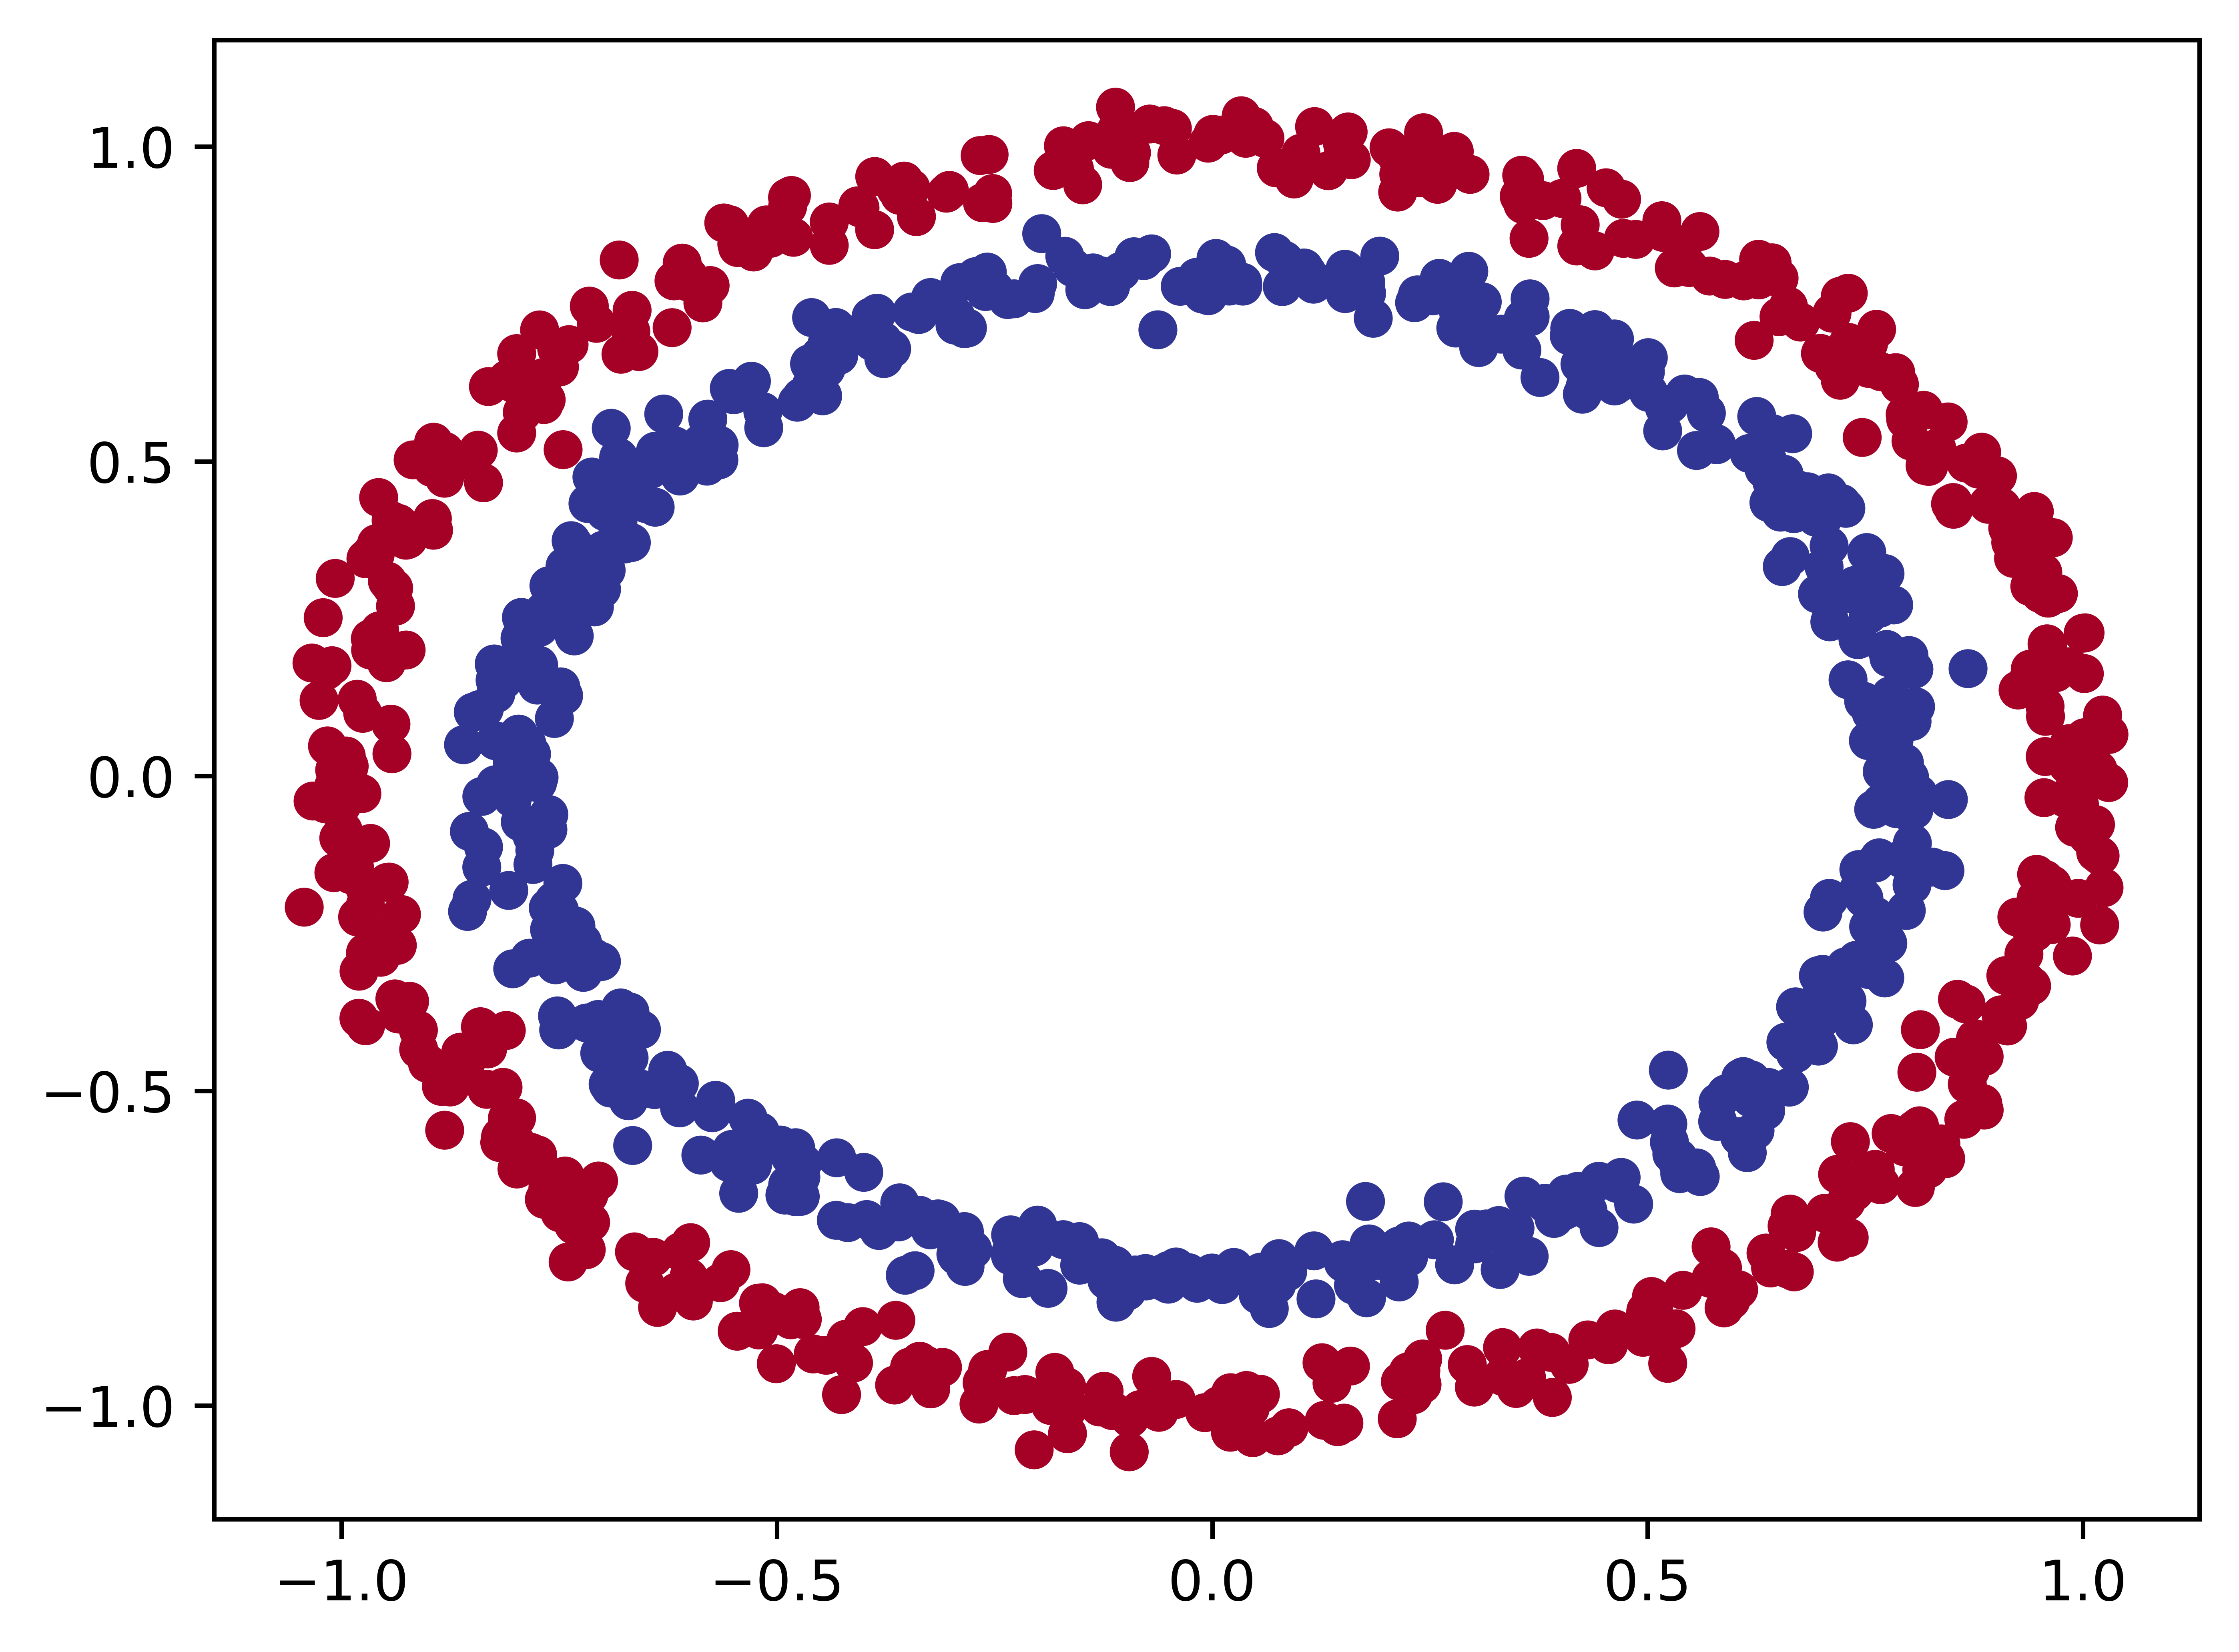

In [3]:
x,y
plt.figure(dpi=1000)
plt.scatter(x[:,0],x[:,1],c=y,cmap=plt.cm.RdYlBu)

In [4]:
x=torch.from_numpy(x).type(torch.float32)

y=torch.from_numpy(y).type(torch.float32)

In [5]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [6]:
## we have the nonlinear weighted and other


## 6.2 building a model with non - linearity

* build a model with non-linear functions

In [7]:
## we can word in 100'rd of dimentions

In [8]:
model=nn.Sequential(
    nn.Linear(in_features=2,out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10,out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10,out_features=1)
).to('mps')
    
        

In [9]:
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=1, bias=True)
)


In [10]:
model.state_dict()

KeyboardInterrupt: 

In [ ]:
loss_fn=nn.BCEWithLogitsLoss()

In [ ]:
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.1)
x_train=x_train.to('mps')
x_test=x_test.to('mps')
y_train=y_train.to('mps')
y_test=y_test.to('mps')

In [ ]:
## 6.3 training a model with non linearity

In [ ]:
x_train

In [ ]:
print(model)

In [ ]:
# random seed
torch.manual_seed(42)

# put all the data on targer device
x_train=x_train.to('mps')
y_train=y_train.to('mps')
x_test=x_test.to('mps')
y_test=y_test.to('mps')
print(x_train)


In [ ]:
def accuracy(y_pred,y_train):
    correct=torch.eq(y_pred,y_train).sum().item()
    acc=correct/len(y_pred)

    return acc

In [ ]:
epochs=3000
a=[]
l=[]
for epoch in range(epochs):
    model.train()
    y_log=model(x_train)
    loss=loss_fn(y_log.squeeze(),y_train)
    l.append(loss.to('cpu').detach().numpy())
    y_p=torch.round(torch.sigmoid(y_log))
    a.append(accuracy(y_p.squeeze(),y_train))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(loss)

In [ ]:
plt.figure(dpi=1000)
plt.subplot(1,2,1)
plt.plot(a)
plt.subplot(1,2,2)
plt.plot(l)

In [ ]:
## device agnostic code is the code used to convert the variables from cpu to the mps

model.state_dict()

In [ ]:
model.state_dict()

* mode parameters mode compute power and thats the tradeof

In [ ]:
with torch.inference_mode():
    test_logits=model(x_test)
    test_preds=torch.round(torch.sigmoid(test_logits))
    test_loss=loss_fn(test_logits.squeeze(),y_test)
print(test_preds)

In [ ]:
test_logits.shape

In [ ]:
print(test_loss)
x_test.shape

In [ ]:
from helper_functions import plot_predictions,plot_decision_boundary
plt.figure(dpi=1000)
plt.subplot(1,2,1)
plot_decision_boundary(model,x_train,y_train)
plt.subplot(1,2,2)
plot_decision_boundary(model,x_test,test_preds)

## Replicating of the non linear function sing raw pytorch functions

* rather than we code them eplicitly we give the tools and let it figure it out to find the best 

In [ ]:
## 
a=torch.arange(-10,10,1,dtype=torch.float32)
a.dtype

In [ ]:
a

In [ ]:
plt.plot(a)

In [ ]:
plt.plot(torch.relu(a))

## tha above is the graphical representation of ReLU function

In [ ]:
def relu(x:torch.Tensor)->torch.Tensor:
    return torch.maximum(torch.tensor(0),x)
    

In [ ]:
relu(a)

## Although ReLU was not no complex and non-linear it was used to reduce the computational complexity

In [ ]:
## ReLU quite simple but powerful

In [ ]:
plt.plot(relu(a))

In [ ]:
## new do the same for the sigmoid

In [ ]:
def sigmoid(x:torch.Tensor)->torch.Tensor:
    return 1/(1+(torch.exp(-x)))

In [ ]:
plt.plot(torch.sigmoid(a))

In [ ]:
plt.plot(sigmoid(a))

## Multiclass classification
* Binary classification = one thing or another 
* Multi-class classification

In [ ]:
##